Load python tools

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Read **input files**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

dir = "/content/drive/My Drive/Higgs_master_26/"
ZJets    = pd.read_csv(dir+'ZJets.csv')
Higgs400 = pd.read_csv(dir+'Higgs2L2Q_M400.csv')
Data     = pd.read_csv(dir+'Real-Data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Plot distributions** (histograms) of event properties

In [4]:
# Function to plot histogram of a given property (first argument of the function)
# arguments: property, x label, range
def plot_hist(v,xl,r):
  plt.hist(v,bins=50,histtype='step', range=r)
  plt.xlabel(xl)
  plt.ylabel('Entries')
  plt.show()

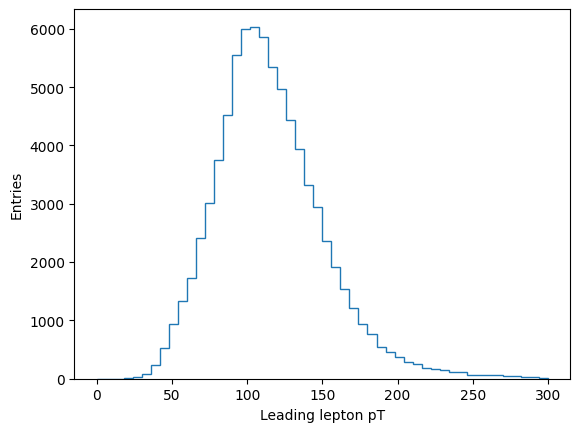

In [5]:
plot_hist(v=Higgs400.ptl1,xl='Leading lepton pT',r=(0,300))

**Compare distributions** of signal and background

In [ ]:
# Function to compare histograms of signal and background
# By default, histograms are normalized to unit area
def compare_dist(s,b,xl,r,d=True,l=0):
  # arguments: signal, background, x label, range, density/counts (optional), log scale (optional)
  labels = ['Signal', 'Background']
  data   = [s, b]
  plt.legend(labels)
  plt.hist(data,bins=50,density=d,histtype='step',label=labels, range=r, log=l)
  plt.xlabel(xl)
  if d:
    plt.ylabel('Density')
  else:
    plt.ylabel('Entries')
  plt.legend()
  plt.show()

Plot histograms

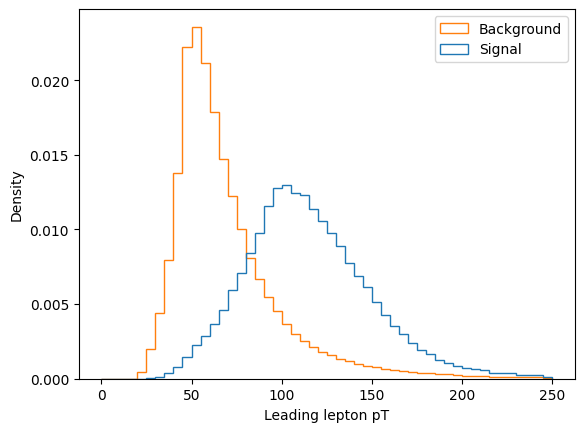

In [ ]:
compare_dist(s=Higgs400.ptl1, b=ZJets.ptl1, xl='Leading lepton pT',r=(0,250))

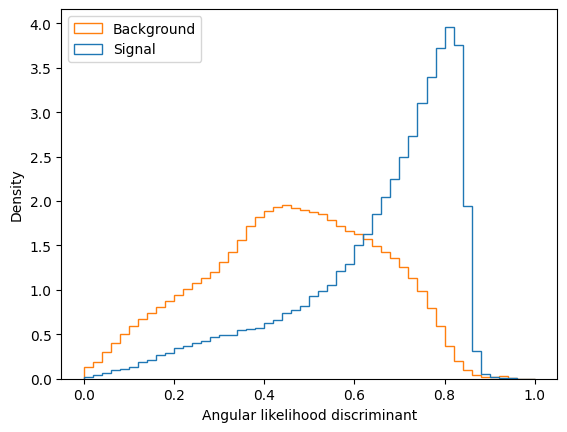

In [ ]:
compare_dist(s=Higgs400.ld, b=ZJets.ld,xl='Angular likelihood discriminant',r=(0,1))

We can **construct new properties from the existing variables and add them to the tables**. First we define a function that operates on columns and returns a result, and then we add the new property as an additional column of the table.

Example: (scalar) sum of transverse momenta of the two leptons:

In [ ]:
 # Function definition
 fptl = lambda row: row.ptl1 + row.ptl2

In [ ]:
# Add new variable as new column
col = ZJets.apply(fptl, axis=1)
ZJets = ZJets.assign(ptl=col.values)

col = Higgs400.apply(fptl, axis=1)
Higgs400 = Higgs400.assign(ptl=col.values)

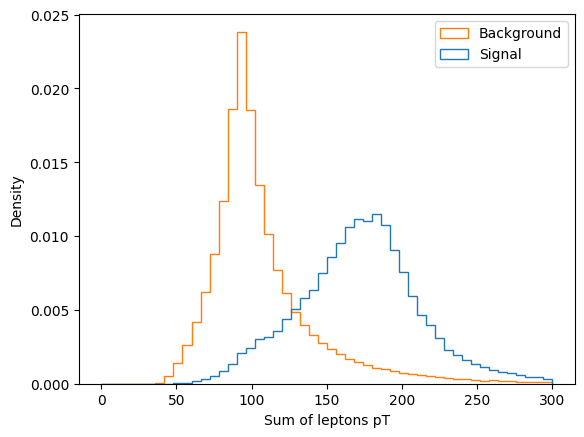

In [ ]:
compare_dist(s=Higgs400.ptl, b=ZJets.ptl, xl='Sum of leptons pT',r=(0,300))

**Exercise**: Following the example above, define functions to calculate  the invariant mass of the two leptons (Z with leptonic decay, **Mll**), the invariant mass of the two jets (Z with hadronic decay, **Mjj**), and the invariant of the two leptons and two jets (Higgs masss in the case of the signal, **Mlljj**). Add columns Mll, Mjj and Mlljj to the real data and the simulations tables.

Fit leptonic and hadronic Z mass

In [ ]:
# Gaussian fit function
def gauss(x, a, m, s):
  return a*np.exp(-0.5*(x-m)**2/s**2)

# function to get (x,y) values to fit from the histogram
def get_fit_data (data, nb, r):
  return np.histogram(data, bins=nb, range=r)

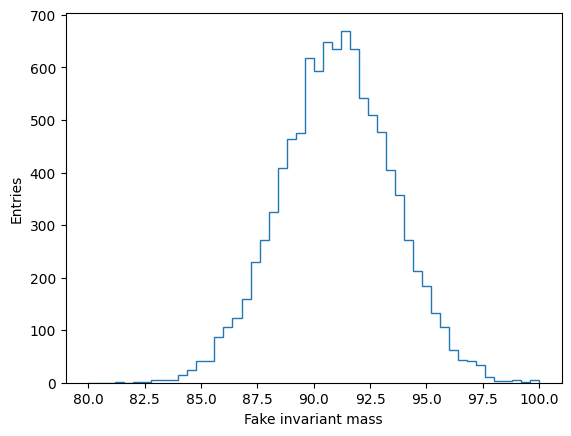

In [ ]:
# Build fake data for illustrating the fit procedure. Replace with data = Higgs400.Mll and data = Higgs400.Mjj for the real leptonic and hadronic Z mass
data = np.random.normal(91, 2.5, 10000)
plot_hist(data,'Fake invariant mass',(80,100))

In [ ]:
# fit the data using the curve_fit function
from scipy.optimize import curve_fit
xrange = (80,100)
nbins = 50
y, x = get_fit_data (data, nbins, xrange)
x = x[:-1] # remove right edge of last bin
pars, cov = curve_fit(f=gauss, xdata=x, ydata=y, p0=[0, 90, 1], bounds=(-np.inf, np.inf))

# print fit parameters and errors
print(pars)
print(np.sqrt(np.diag(cov)))

[647.46726902  90.8194775    2.45870618]
[5.38850616 0.02362784 0.02362832]


Plots results

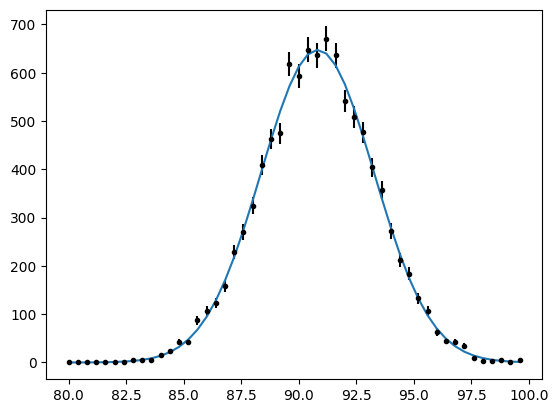

In [ ]:
plt.errorbar(x, y, yerr=np.sqrt(y), fmt='.k')
plt.plot(x, gauss(x,*pars))

# Data Analysis

Function to **plot data with statistical error bars**

In [ ]:
def plot_data(v,xl,r,l=0):
  # arguments: variable, x label, range, log scale (optional)
  counts, bins = np.histogram(v,bins=50, range=r)
  errors = np.sqrt(counts)
  plt.errorbar(bins[:-1],counts, yerr=errors, fmt='.k');
  if l==1:
    plt.yscale('log')
  plt.xlabel(xl)
  plt.ylabel('Entries')
  plt.show()

One can apply **selection cuts**, selecting only those events (rows in the panda tables) which verify certain conditions, by defining a boolean variable with the conditions. For example, to select the values of Mlljj in real data (DataSel) of those events that verify that the pt of the first lepton (ptl1) is larger than 50 and the angular variable discriminant (ld) is larger than 0.7:


```
# Define selection cuts
Mycuts = (Data.ptl1>50) & (Data.ld>0.7)
# Select Mlljj values that verify selections cuts
DataSel=Data.loc[Mycuts, 'Mlljj']
# Plot the histrogram for Mlljj of the selected events
plot_data(DataSel,'lljj invariant mass',(100,800))
```






**Compare data with simulation predictions**. The simulations (signal  and background) have to be normalized to the integrated luminosity in data so that equivalent amounts are compared. Usually, the simulations correspond to a larger luminosity to reduce the statistical uncertainty. The luminosity of the data is given by the number of experiments (collisions produced by the accelerator).





In [ ]:
# luminosities in data and in simulations
lumData = 19.7
lumZj   = 33.4
lumH350 = 405
lumH400 = 541
lumH500 = 1271

Function to **plot the histogram of a property together for real data (d), expected background (b) and signal (s)** from simulation. The simulations are normalized to the luminosity of the data by introducing appropriate event weights (the counts of the histogram are the weights instead of 1 per event)

In [ ]:
def compare_data_sim(d,b,s,lumH,xl,r,l=0):
  # arguments: data, background, signal, signal luminosity, x label, range, log scale (optional)
  # data
  counts, bins = np.histogram(d,bins=50, range=r)
  errors = np.sqrt(counts)
  plt.errorbar(bins[:-1],counts, yerr=errors, fmt='.k');

  # signal + background simulation normalized to data
  wgts_b = (lumData/lumZj)*np.ones_like(b)
  counts_b, bins_b = np.histogram(b,bins=50, range=r, weights=wgts_b)
  wgts_s = (lumData/lumH)*np.ones_like(s)
  counts_s, bins_s = np.histogram(s,bins=50, range=r, weights=wgts_s)

  # signal + background
  plt.plot(bins[:-1],counts_b+counts_s, label='signal + background')
  # only signal
  plt.plot(bins[:-1],counts_s, label='signal')
  # only background
  plt.plot(bins[:-1],counts_b, label='background')

  if l==1:
    plt.yscale('log')
  plt.xlabel(xl)
  plt.ylabel('Entries')
  plt.legend()
  plt.show()

Without selection cuts

In [ ]:
compare_data_sim(d=Data.Mlljj, b=ZJets.Mlljj, s=Higgs400.Mlljj, lumH=lumH400, xl='lljj invariant mass', r=(100,800), l=0)

AttributeError: 'DataFrame' object has no attribute 'Mlljj'

Comparison of data vs simulation with **selection cuts** (note that the same selection cuts have to be defined for the real data, the signal and the background, using the corresponding variables)

In [ ]:
DataSel  = Data.loc[Mycuts, 'Mlljj']
HiggsSel = Higgs400.loc[MycutsH, 'Mlljj']
ZJetsSel = ZJets.loc[MycutsZj, 'Mlljj']

compare_data_sim(DataSel, ZJetsSel, HiggsSel, lumH400, 'lljj invariant mass', (100,800), l=0)

NameError: name 'Mycuts' is not defined

Fit data after selection cuts to signal (gaussian) + background (exponential)

In [ ]:
from scipy.optimize import curve_fit

# Fit function (exponential + gaussian)
def exp_gauss(x, a, b, c, m, s):
    return a*np.exp(b*x) + c*np.exp(-0.5*(x-m)**2/s**2)

# function to get (x,y) values to fit from the histogram
def get_fit_data (data, nb, r):
  return np.histogram(data, bins=nb, range=r)

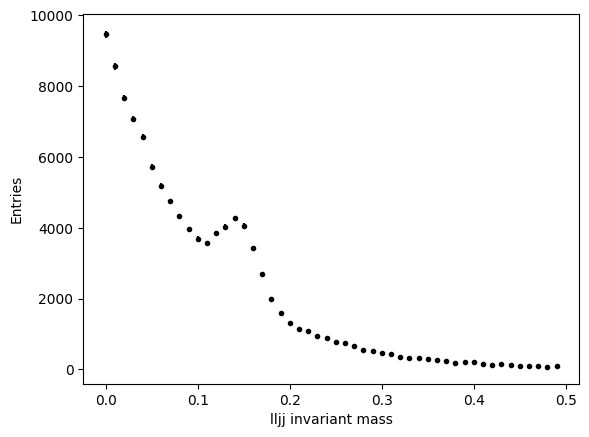

In [ ]:
# Build fake data to illustrate the exponential+gaussian fit. Replace by data = Data.Mlljj for the real case
datafake = np.concatenate((np.random.exponential(0.1,100000), np.random.normal(0.15, 0.02, 10000)))
plot_data(datafake,'lljj invariant mass',(0,0.5))

Run the fit

In [ ]:
# run the fit
xrange = (0.01,0.4)  # restrict the fit to this range of values in the x asis
nbins = 40
y, x = get_fit_data (datafake, nbins, xrange)  # get (x,y) values from the histogram (x is the position of each bin, and y the counts for that bin)
x = x[:-1] # remove right edge of last bin
# run the fit. p0 are starting values of the fit parameters (can be given to accelerate convergence of the fit).
# Bounds are posible values of parameters. Can also be given to help the fit.
pars, cov = curve_fit(f=exp_gauss, xdata=x, ydata=y, p0=[0, 0, 0, 0.1, 0.1], bounds=(-np.inf, np.inf))

# Print fit parameters and errors
print(pars)
print(np.sqrt(np.diag(cov))) # the variance of the fit parameters are the diagonal elements of the covariance matrix

[ 9.32412071e+03 -1.00403485e+01  2.00667579e+03  1.44729889e-01
  1.98082714e-02]
[2.45461063e+01 4.57172495e-02 2.30888091e+01 2.47344981e-04
 2.84789227e-04]


Plot data and fit

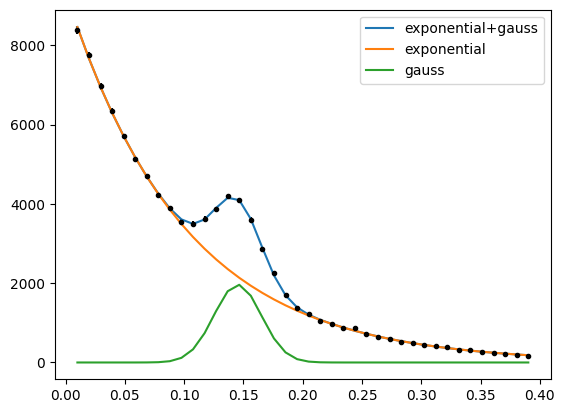

In [ ]:
plt.errorbar(x, y, yerr=np.sqrt(y), fmt='.k')
plt.plot(x, exp_gauss(x,*pars), label='exponential+gauss')               # plot exponential + gaussian function with the fit parameters
plt.plot(x, exp_gauss(x,pars[0], pars[1], 0, 0, 1), label='exponential') # plot only exponential component (use exponential parameters from the fits and sett gaussian parameters to 0)
plt.plot(x, exp_gauss(x,0, 0, pars[2], pars[3], pars[4]), label='gauss') # only gaussian component (use gaussian parameters from the fit and set exponential parameters to 0)
plt.legend()